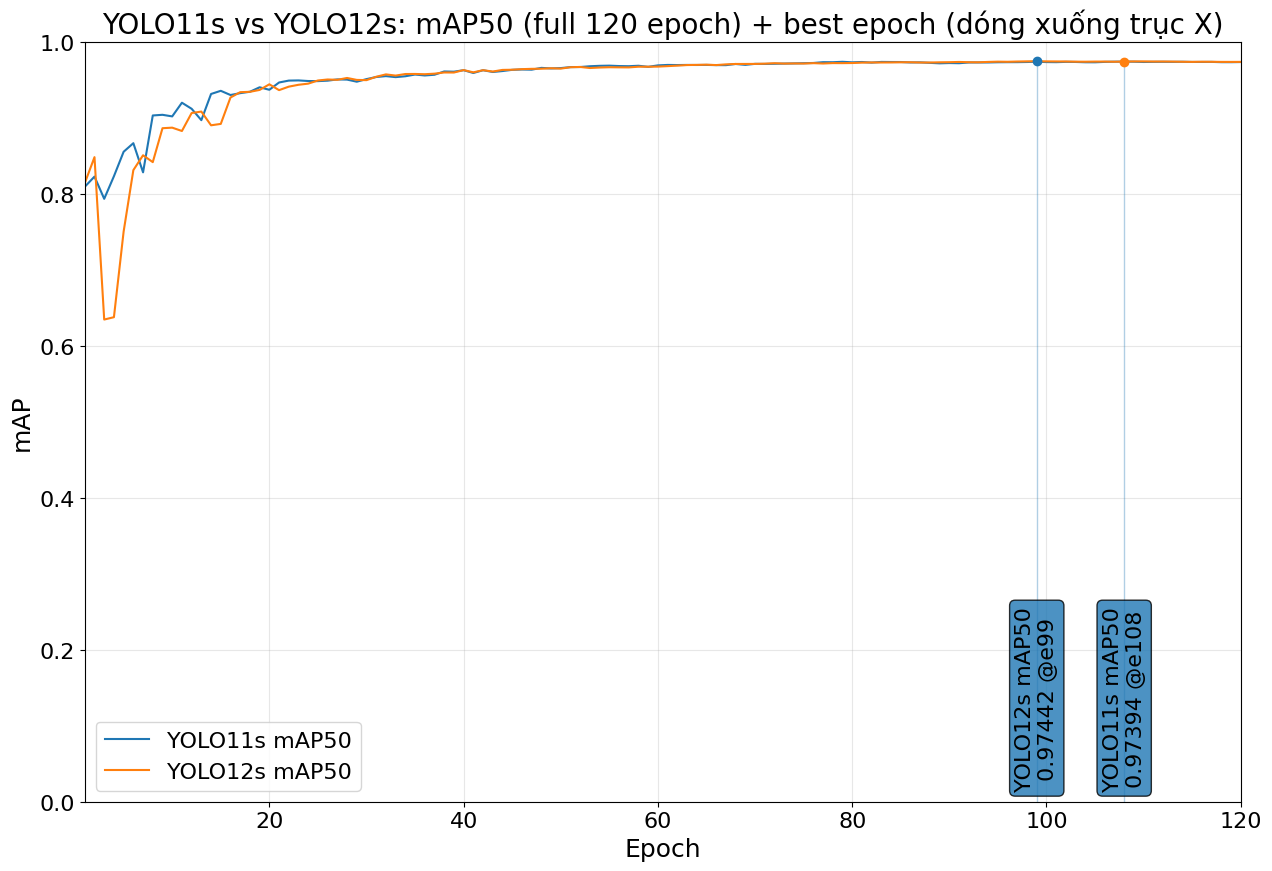

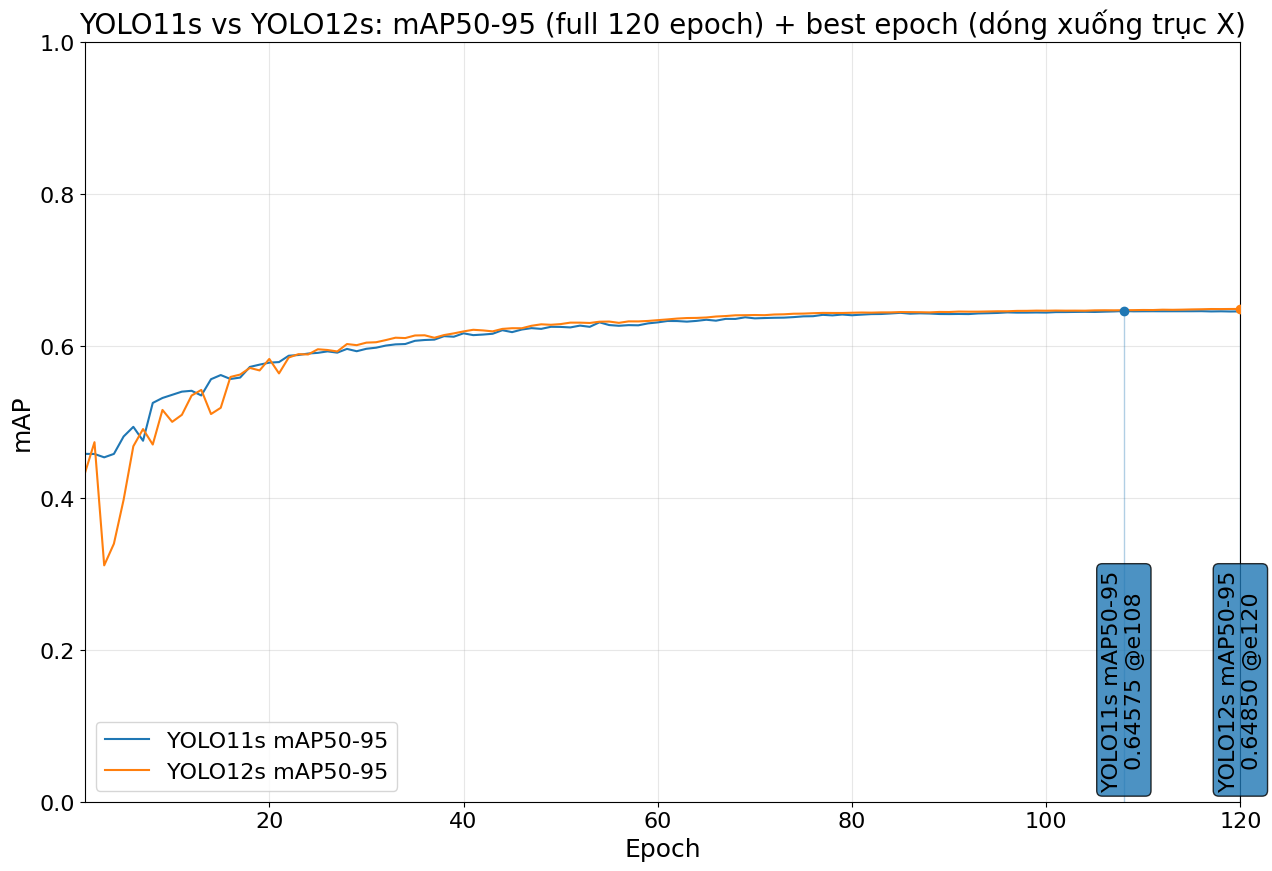

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ======= GLOBAL FONT SIZES (tăng thêm nếu muốn) =======
plt.rcParams.update({
    "font.size": 16,          # base
    "axes.titlesize": 20,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

yolo11_csv = "./results/runs/detect/train/results.csv"
yolo12_csv = "./results_Yolo12/runs/detect/train/results.csv"

df11 = pd.read_csv(yolo11_csv).sort_values("epoch")
df12 = pd.read_csv(yolo12_csv).sort_values("epoch")

max_epoch = 120
epoch_index = pd.DataFrame({"epoch": np.arange(1, max_epoch + 1)})

m11 = epoch_index.merge(
    df11[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]],
    on="epoch", how="left"
)
m12 = epoch_index.merge(
    df12[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]],
    on="epoch", how="left"
)

def best_point(df, col):
    s = df[col].astype(float)
    idx = s.idxmax()  # ignores NaN
    return int(df.loc[idx, "epoch"]), float(df.loc[idx, col])

def place_bottom_labels(ax, marks, cluster_gap=8):
    """
    Dóng xuống trục X + label ở đáy, tự né nhau bằng:
    - gom cụm epoch gần nhau (<= cluster_gap)
    - lệch ngang theo thứ tự trong cụm
    - so le y-offset theo tầng
    """
    y0, y1 = ax.get_ylim()
    y_min = y0

    ms = sorted(marks, key=lambda x: x[1])
    clusters, cur = [], []
    for item in ms:
        if not cur:
            cur = [item]
        else:
            if abs(item[1] - cur[-1][1]) <= cluster_gap:
                cur.append(item)
            else:
                clusters.append(cur)
                cur = [item]
    if cur:
        clusters.append(cur)

    y_offsets = [8, 26, 44, 62]
    def x_offsets(n):
        if n == 1:
            return [0]
        step = 22
        mid = (n - 1) / 2
        return [int((i - mid) * step) for i in range(n)]

    for cluster in clusters:
        xo = x_offsets(len(cluster))
        for i, (label, e, v) in enumerate(cluster):
            ax.vlines(e, ymin=y_min, ymax=v, alpha=0.35, linewidth=1)
            ax.scatter([e], [v], zorder=5)

            ax.annotate(
                f"{label}\n{v:.5f} @e{e}",
                xy=(e, y_min),
                xytext=(xo[i], y_offsets[i % len(y_offsets)]),
                textcoords="offset points",
                ha="center", va="bottom",
                rotation=90,
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.8),
                clip_on=False
            )

def plot_metric(metric_col, title, line_labels):
    fig, ax = plt.subplots(figsize=(13, 9))

    ax.plot(m11["epoch"], m11[metric_col], label=line_labels[0])
    ax.plot(m12["epoch"], m12[metric_col], label=line_labels[1])

    # best marks (2 cái)
    e11, v11 = best_point(m11, metric_col)
    e12, v12 = best_point(m12, metric_col)
    marks = [
        (line_labels[0], e11, v11),
        (line_labels[1], e12, v12),
    ]

    ax.set_xlim(1, max_epoch)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left")

    place_bottom_labels(ax, marks, cluster_gap=8)

    plt.subplots_adjust(bottom=0.28)
    plt.tight_layout()
    plt.show()

# ===== Plot 1: mAP50 =====
plot_metric(
    metric_col="metrics/mAP50(B)",
    title="YOLO11s vs YOLO12s: mAP50 (full 120 epoch) + best epoch (dóng xuống trục X)",
    line_labels=("YOLO11s mAP50", "YOLO12s mAP50")
)

# ===== Plot 2: mAP50-95 =====
plot_metric(
    metric_col="metrics/mAP50-95(B)",
    title="YOLO11s vs YOLO12s: mAP50-95 (full 120 epoch) + best epoch (dóng xuống trục X)",
    line_labels=("YOLO11s mAP50-95", "YOLO12s mAP50-95")
)


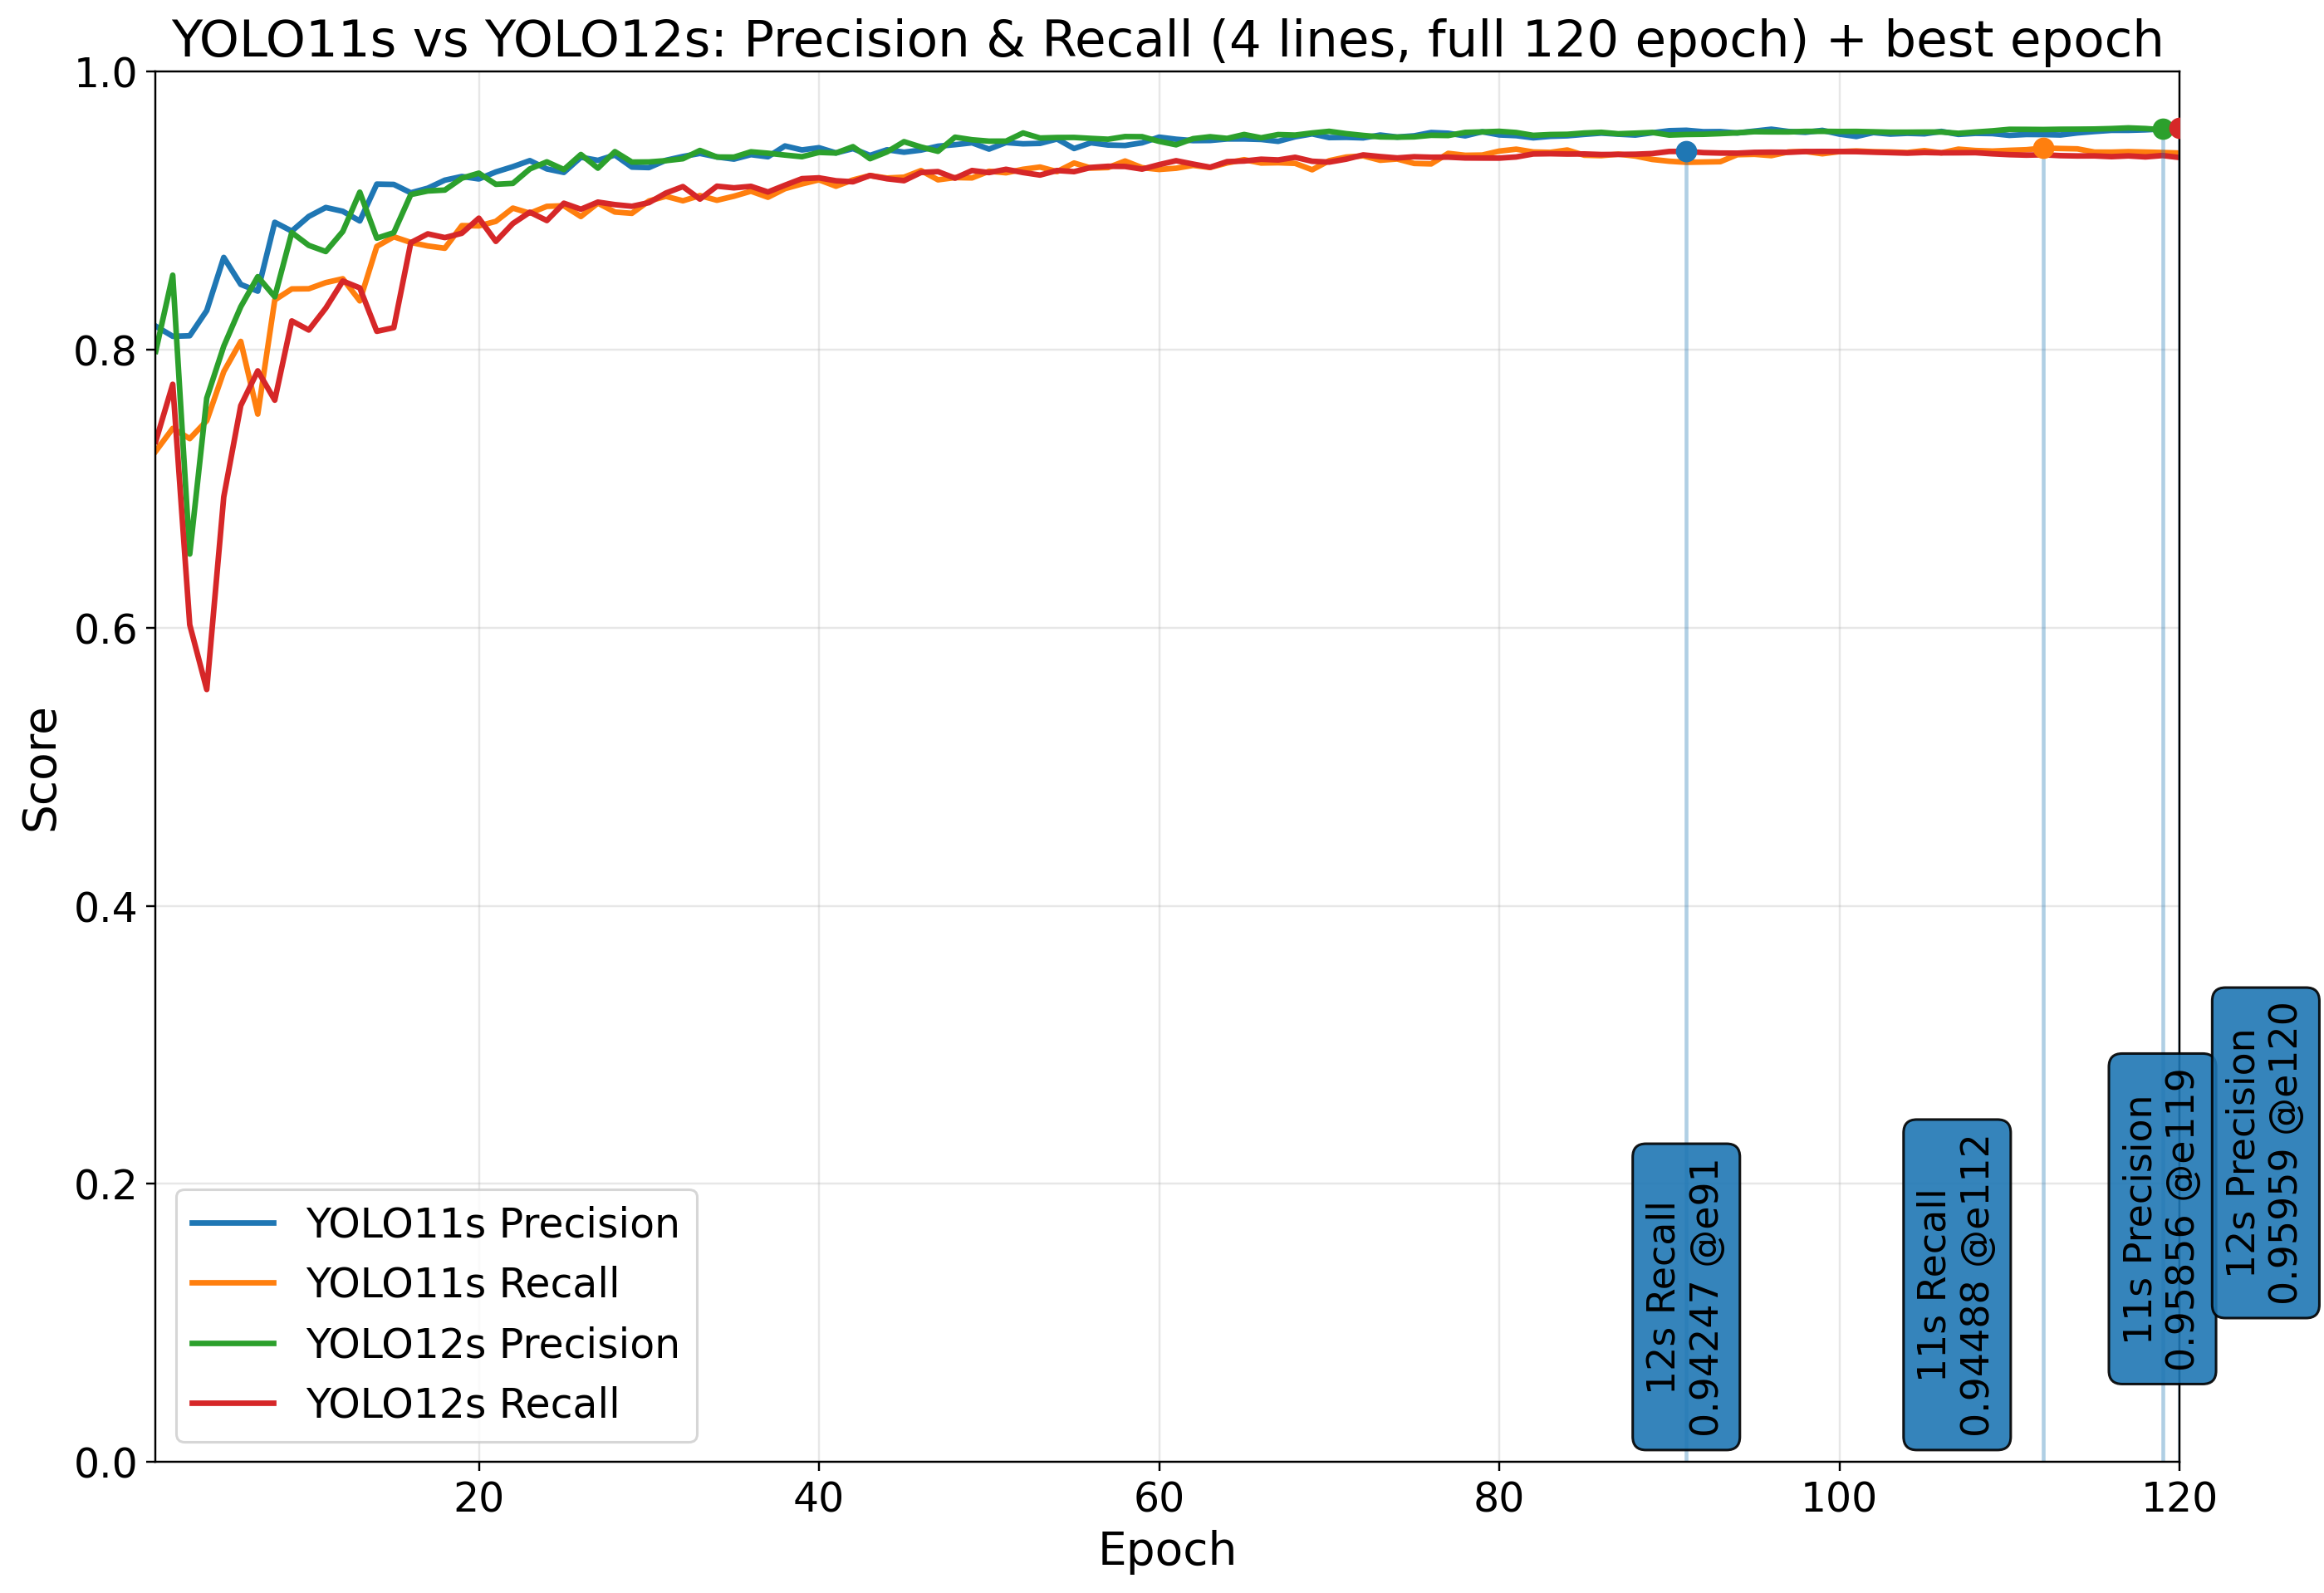

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ======= GLOBAL FONT SIZES =======
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

yolo11_csv = "./results/runs/detect/train/results.csv"
yolo12_csv = "./results_Yolo12/runs/detect/train/results.csv"

df11 = pd.read_csv(yolo11_csv).sort_values("epoch")
df12 = pd.read_csv(yolo12_csv).sort_values("epoch")

max_epoch = 120
epoch_index = pd.DataFrame({"epoch": np.arange(1, max_epoch + 1)})

m11 = epoch_index.merge(
    df11[["epoch", "metrics/precision(B)", "metrics/recall(B)"]],
    on="epoch", how="left"
)
m12 = epoch_index.merge(
    df12[["epoch", "metrics/precision(B)", "metrics/recall(B)"]],
    on="epoch", how="left"
)

def best_point(df, col):
    s = df[col].astype(float)
    idx = s.idxmax()  # ignores NaN
    return int(df.loc[idx, "epoch"]), float(df.loc[idx, col])

def place_bottom_labels(ax, marks, cluster_gap=10):
    """
    Dóng xuống trục X + label ở đáy, né nhau bằng clustering + offset points.
    marks: list of (label, epoch, value)
    """
    y_min = ax.get_ylim()[0]

    ms = sorted(marks, key=lambda x: x[1])
    clusters, cur = [], []
    for item in ms:
        if not cur:
            cur = [item]
        else:
            if abs(item[1] - cur[-1][1]) <= cluster_gap:
                cur.append(item)
            else:
                clusters.append(cur)
                cur = [item]
    if cur:
        clusters.append(cur)

    y_offsets = [10, 36, 62, 88, 114, 140]
    def x_offsets(n):
        if n == 1:
            return [0]
        step = 34
        mid = (n - 1) / 2
        return [int((i - mid) * step) for i in range(n)]

    for cluster in clusters:
        xo = x_offsets(len(cluster))
        for i, (label, e, v) in enumerate(cluster):
            ax.vlines(e, ymin=y_min, ymax=v, alpha=0.35, linewidth=1.5)
            ax.scatter([e], [v], s=55, zorder=6)
            ax.annotate(
                f"{label}\n{v:.5f} @e{e}",
                xy=(e, y_min),
                xytext=(xo[i], y_offsets[i % len(y_offsets)]),
                textcoords="offset points",
                ha="center", va="bottom",
                rotation=90,
                fontsize=15,
                bbox=dict(boxstyle="round,pad=0.35", alpha=0.9),
                clip_on=False
            )

# ===== 1 chart / 4 lines =====
fig, ax = plt.subplots(figsize=(13, 9), dpi=220)

ax.plot(m11["epoch"], m11["metrics/precision(B)"], linewidth=2.2, label="YOLO11s Precision")
ax.plot(m11["epoch"], m11["metrics/recall(B)"],    linewidth=2.2, label="YOLO11s Recall")
ax.plot(m12["epoch"], m12["metrics/precision(B)"], linewidth=2.2, label="YOLO12s Precision")
ax.plot(m12["epoch"], m12["metrics/recall(B)"],    linewidth=2.2, label="YOLO12s Recall")

ax.set_xlim(1, max_epoch)
ax.set_ylim(0, 1.0)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("YOLO11s vs YOLO12s: Precision & Recall (4 lines, full 120 epoch) + best epoch")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

# 4 best marks (per-line)
marks = [
    ("11s Precision", *best_point(m11, "metrics/precision(B)")),
    ("11s Recall",    *best_point(m11, "metrics/recall(B)")),
    ("12s Precision", *best_point(m12, "metrics/precision(B)")),
    ("12s Recall",    *best_point(m12, "metrics/recall(B)")),
]

place_bottom_labels(ax, marks, cluster_gap=12)

plt.subplots_adjust(bottom=0.42)  # chừa nhiều chỗ cho label dọc
plt.tight_layout()
plt.show()


In [30]:
from ultralytics import YOLO

# YOLO11s
m11 = YOLO("./results/runs/detect/train/weights/best.pt")
m11.val(data="./results/waid.yaml", plots=True, project="pr_compare", name="yolo11s_val")

# YOLO12s
m12 = YOLO("./results_Yolo12/runs/detect/train/weights/best.pt")
m12.val(data="./results/waid.yaml", plots=True, project="pr_compare", name="yolo12s_val")

Ultralytics 8.3.239  Python-3.10.0 torch-2.9.1+cpu CPU (Intel Core i3-10105 3.70GHz)
YOLO11s summary (fused): 100 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 383.9210.0 MB/s, size: 80.0 KB)
val: Scanning E:\WAID_Yolo11\WAID\labels\valid... 2873 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2873/2873 2.2Kit/s 1.3s0.0s
val: New cache created: E:\WAID_Yolo11\WAID\labels\valid.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 180/180 2.7s/it 8:073.0ss
                   all       2873      46703      0.955      0.943      0.974      0.647
                 sheep        830      26063      0.975      0.973      0.985      0.672
                cattle        932      12605      0.973      0.956      0.982      0.685
                  seal        701       4926       0.96      0.975      0.987      0.728
               camelus        154       1271      0.936      0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001836DF56A40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

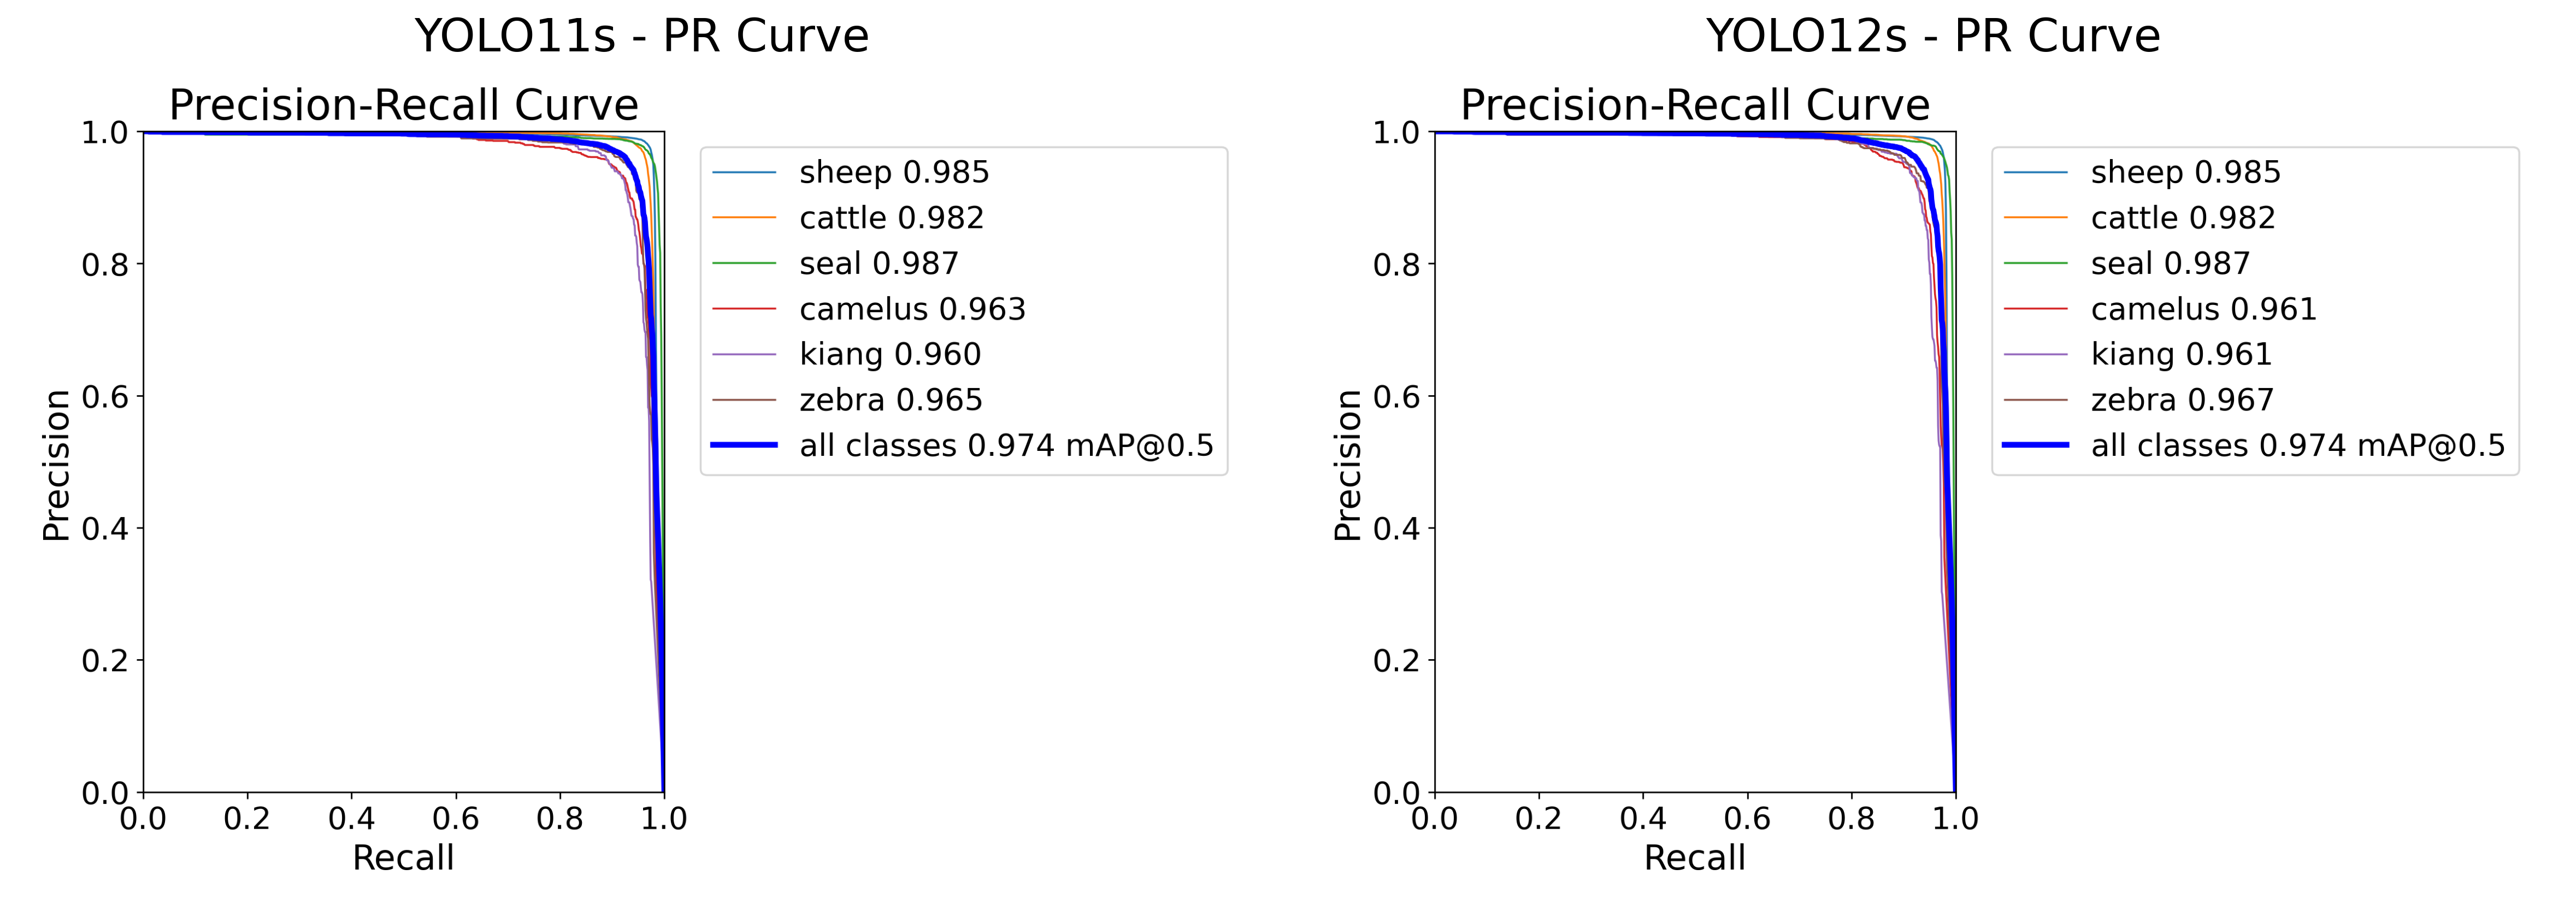

In [34]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

pr11 = Path("./pr_compare/yolo11s_val/BoxPR_curve.png")
pr12 = Path("./pr_compare/yolo12s_val/BoxPR_curve.png")

img11 = Image.open(pr11)
img12 = Image.open(pr12)

plt.figure(figsize=(16, 8), dpi=300)

ax1 = plt.subplot(1, 2, 1); ax1.imshow(img11); ax1.set_title("YOLO11s - PR Curve", fontsize=20); ax1.axis("off")
ax2 = plt.subplot(1, 2, 2); ax2.imshow(img12); ax2.set_title("YOLO12s - PR Curve", fontsize=20); ax2.axis("off")

plt.tight_layout()
plt.savefig("PR_curve_compare.png", dpi=300, bbox_inches="tight")
plt.show()


In [36]:
from pathlib import Path
from PIL import Image

cm11 = Path("./pr_compare/yolo11s_val/confusion_matrix.png")
cm12 = Path("./pr_compare/yolo12s_val/confusion_matrix.png")

img11 = Image.open(cm11).convert("RGB")
img12 = Image.open(cm12).convert("RGB")

# resize cùng chiều cao
h = max(img11.height, img12.height)
def resize_to_h(im, h):
    w = int(im.width * (h / im.height))
    return im.resize((w, h))

img11 = resize_to_h(img11, h)
img12 = resize_to_h(img12, h)

gap = 30
canvas = Image.new("RGB", (img11.width + gap + img12.width, h), (255, 255, 255))
canvas.paste(img11, (0, 0))
canvas.paste(img12, (img11.width + gap, 0))

out = Path("confusion_matrix_compare.png")
canvas.save(out, quality=95)
print("Saved:", out.resolve())


Saved: E:\WAID_Yolo11\confusion_matrix_compare.png
